In [273]:
import pandas as pd
import numpy as np

In [274]:
raw = pd.read_csv('https://hilpisch.com/pyalgo_eikon_eod_data.csv',
                            index_col=0, parse_dates=True).dropna()

In [275]:
data = pd.DataFrame(raw['XAU='])

In [276]:
data.rename(columns={'XAU=': 'price'}, inplace=True) 

In [277]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [278]:
data['position'] = np.sign(data['returns'])

In [279]:
data['strategy'] = data['position'].shift(1) * data['returns']

<Axes: xlabel='Date'>

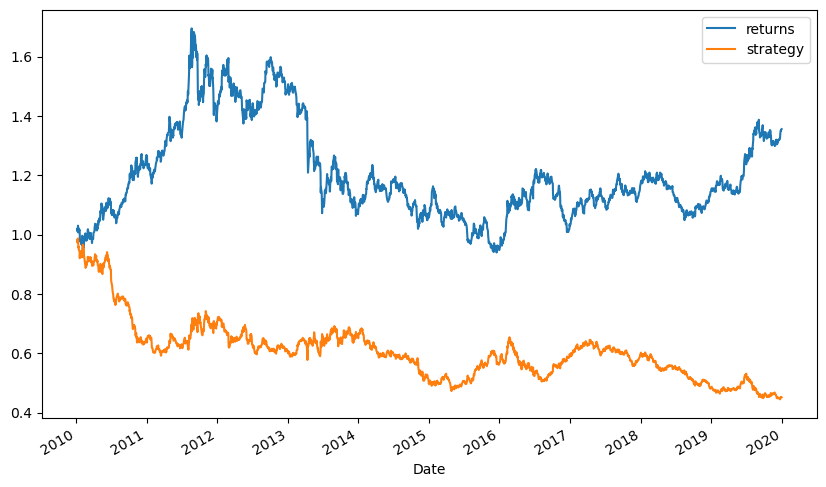

In [280]:
data[['returns', 'strategy']].dropna().cumsum(

).apply(np.exp).plot(figsize=(10,6))

In [281]:
data['position'] = np.sign(data['returns'].rolling(3).mean())

In [282]:
data['strategy'] = data['position'].shift(1) * data['returns']

<Axes: xlabel='Date'>

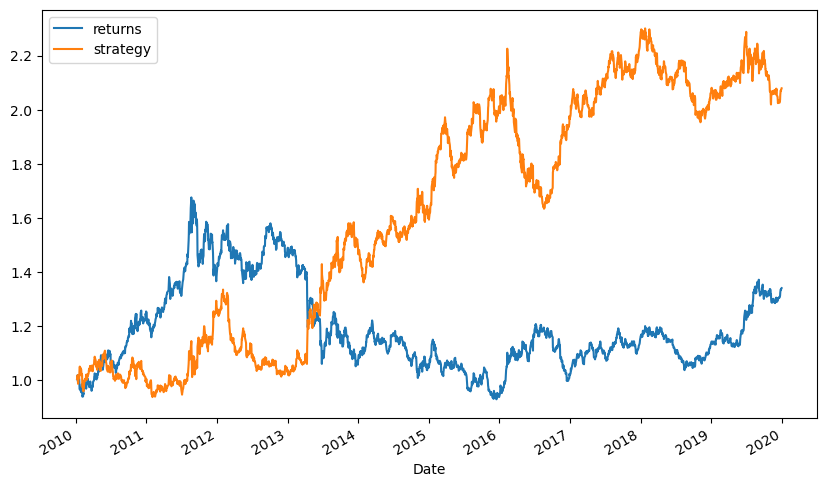

In [283]:
data[['returns', 'strategy']].dropna().cumsum(
).apply(np.exp).plot(figsize=(10,6))

In [284]:
data['position'] = np.sign(data['returns'].rolling(2).mean())

In [285]:
data['strategy'] = data['position'].shift(1) * data['returns']

<Axes: xlabel='Date'>

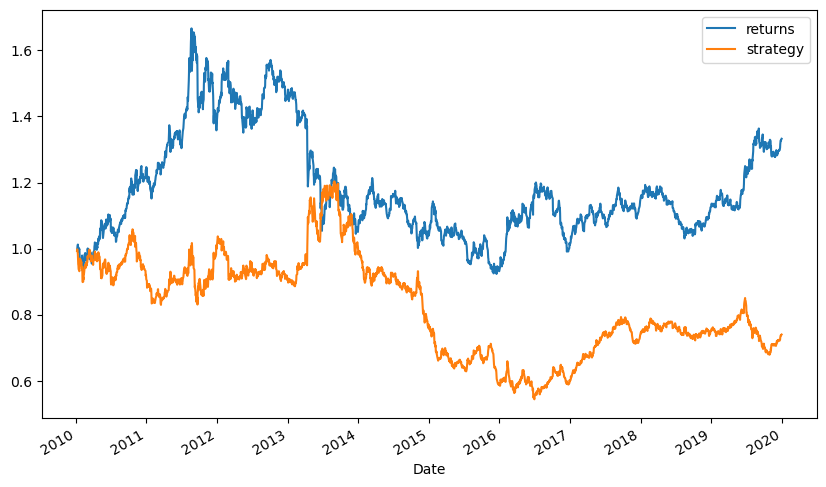

In [286]:
data[['returns', 'strategy']].dropna().cumsum(
).apply(np.exp).plot(figsize=(10,6))

In [287]:
import yfinance as yf

In [288]:
df = yf.download("BTC-USD",  interval="1m", period="7d")

[*********************100%***********************]  1 of 1 completed


In [289]:
import pandas as pd

In [290]:
df = df.rename(columns={
    'Open': 'OPEN',
    'High': 'HIGH',
    'Low': 'LOW',
    'Close': 'CLOSE',
    'Volume': 'VOLUME'
})

In [291]:
df['COUNT'] = df['VOLUME']

In [292]:
print(df.columns)



MultiIndex([( 'CLOSE', 'BTC-USD'),
            (  'HIGH', 'BTC-USD'),
            (   'LOW', 'BTC-USD'),
            (  'OPEN', 'BTC-USD'),
            ('VOLUME', 'BTC-USD'),
            ( 'COUNT',        '')],
           names=['Price', 'Ticker'])


In [293]:
# MultiIndex → 単純な列名に変換
df.columns = [col[0] for col in df.columns]

# 列順を揃える
df = df[['HIGH', 'LOW', 'OPEN', 'CLOSE', 'COUNT', 'VOLUME']]


In [294]:
df['returns'] = np.log(df['CLOSE'] / df['CLOSE'].shift(1))

In [295]:
to_plot = ['returns']

In [296]:
for m in [1, 3, 5, 7, 9]:
    df[f'position_{m}'] = np.sign(df['returns'].rolling(m).mean())
    df[f'strategy_{m}'] = df[f'position_{m}'].shift(1) * df['returns']
    to_plot.append(f'strategy_{m}')

<Axes: title={'center': 'BTC-USD intraday momentum (7 days)'}, xlabel='Datetime'>

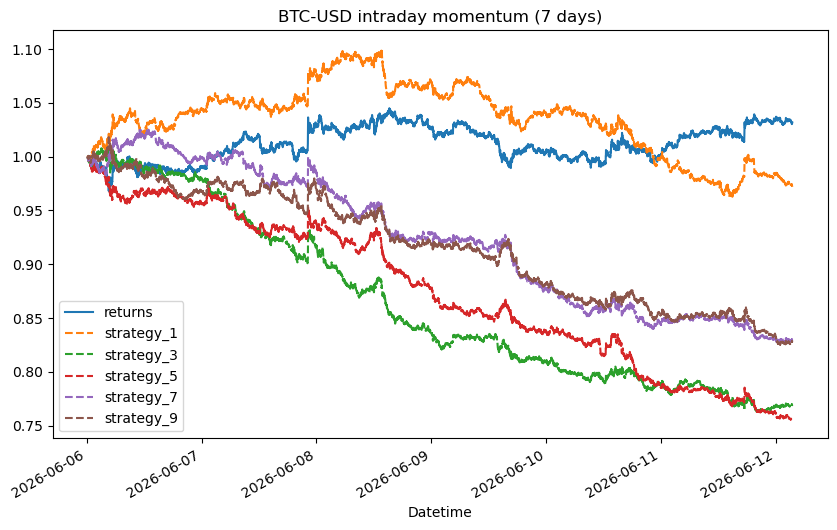

In [297]:
df[to_plot].dropna().cumsum().apply(np.exp).plot(
  title='BTC-USD intraday momentum (7 days)',
  figsize=(10,6),
  style=['-', '--', '--', '--', '--', '--']
)